In [ ]:
import sys
sys.path.append('..')

from src.black_scholes import *
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

spotStartRange = 1
spotEndRange = 200
spotSteps = 600

In [ ]:
print(f"Call price:  {call_price(S, K, T, r, sigma):.4f}")
print(f"Put price:   {put_price(S, K, T, r, sigma):.4f}")
print(f"Delta call:  {delta_call(S, K, T, r, sigma):.4f}")
print(f"Delta put:   {delta_put(S, K, T, r, sigma):.4f}")
print(f"Gamma:       {gamma(S, K, T, r, sigma):.4f}")
print(f"Vega:        {vega(S, K, T, r, sigma):.4f}")
print(f"Theta call:  {theta_call(S, K, T, r, sigma):.4f}")
print(f"Theta put:   {theta_put(S, K, T, r, sigma):.4f}")
print(f"Rho call:    {rho_call(S, K, T, r, sigma):.4f}")
print(f"Rho put:     {rho_put(S, K, T, r, sigma):.4f}")

Call price:  10.4506
Put price:   5.5735
Delta call:  0.6368
Delta put:   -0.3632
Gamma:       0.0188
Vega:        37.5240
Theta call:  -6.4140
Theta put:   -1.0908
Rho call:    53.2325
Rho put:     -41.8905


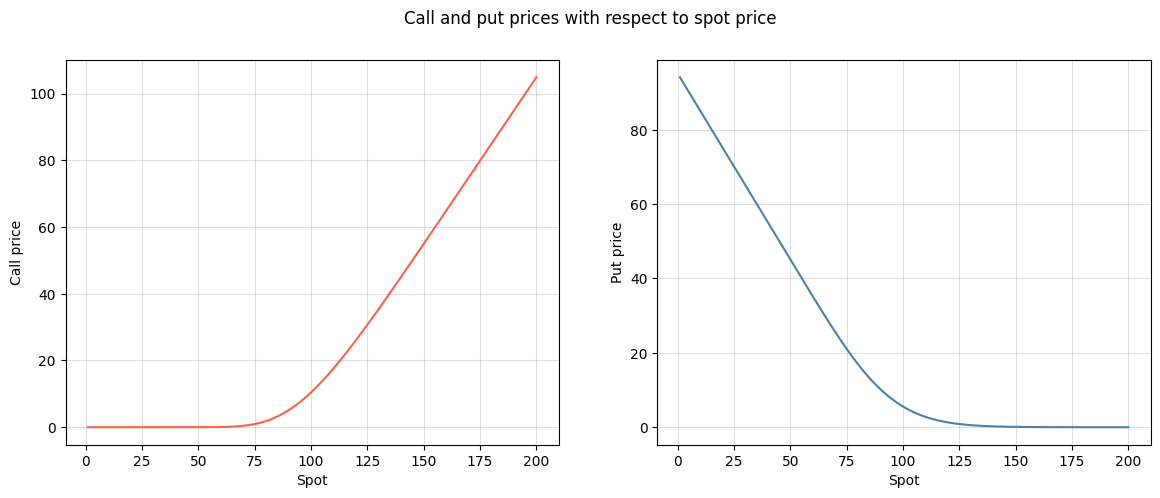

In [ ]:
spots = np.linspace(spotStartRange, spotEndRange, spotSteps)
calls = [call_price(spot, K, T, r, sigma) for spot in spots]
puts = [put_price(spot, K, T, r, sigma) for spot in spots]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

fig.suptitle('Call and put prices with respect to spot price')

ax[0].plot(spots, calls, color='tomato')
ax[0].set_xlabel('Spot')
ax[0].set_ylabel('Call price')
ax[0].grid(True, alpha=0.4)

ax[1].plot(spots, puts, color='steelblue')
ax[1].set_xlabel('Spot')
ax[1].set_ylabel('Put price')
ax[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

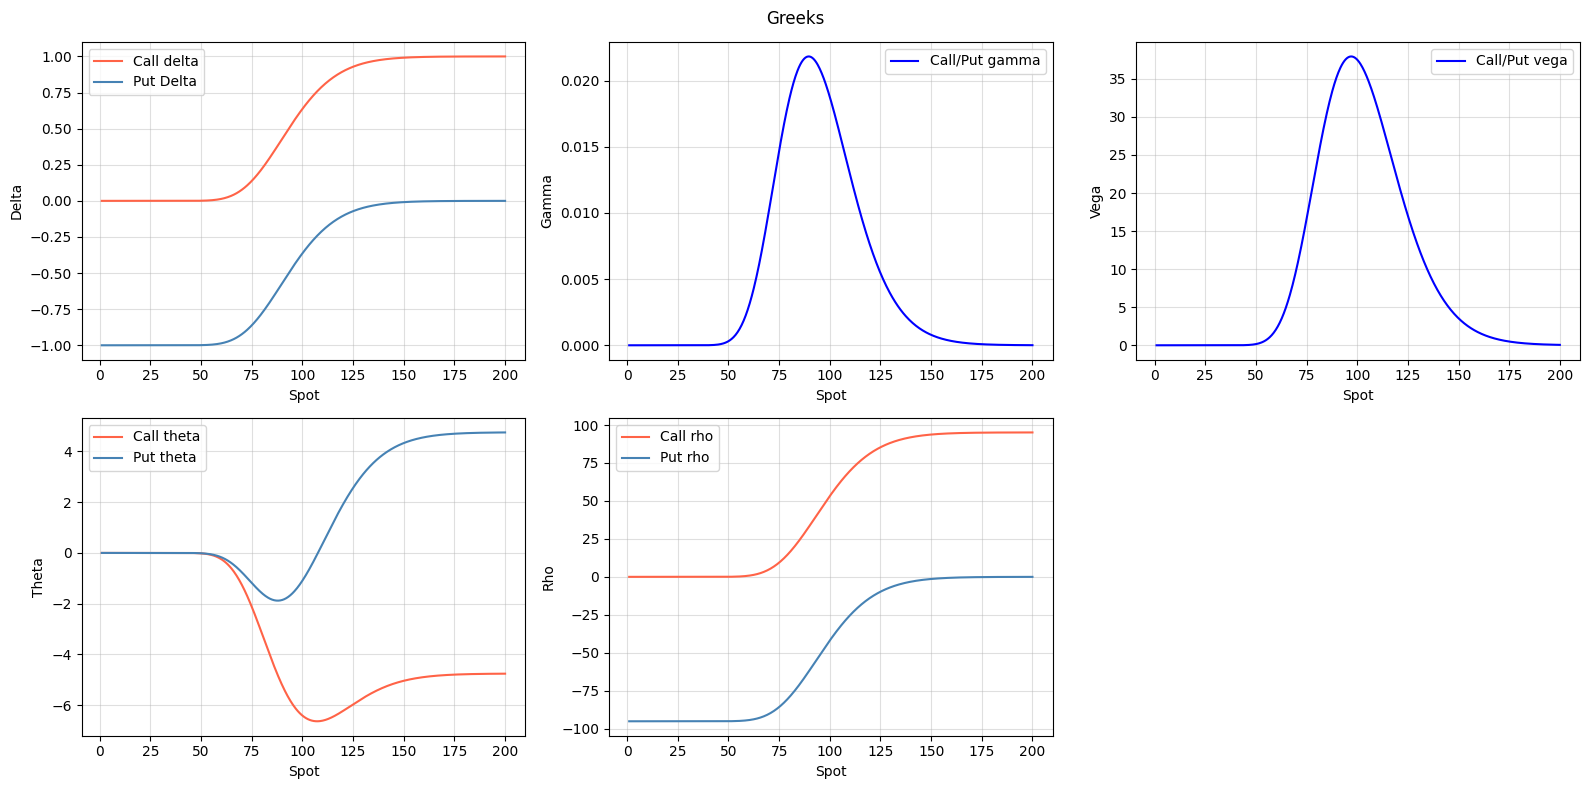

In [ ]:
spots = np.linspace(spotStartRange, spotEndRange, spotSteps)
deltaCallList = [delta_call(spot, K, T, r, sigma) for spot in spots]
deltaPutList = [delta_put(spot, K, T, r, sigma) for spot in spots]
gammaList = [gamma(spot, K, T, r, sigma) for spot in spots]
vegaList = [vega(spot, K, T, r, sigma) for spot in spots]
thetaCallList = [theta_call(spot, K, T, r, sigma) for spot in spots]
thetaPutList = [theta_put(spot, K, T, r, sigma) for spot in spots]
rhoCallList = [rho_call(spot, K, T, r, sigma) for spot in spots]
rhoPutList = [rho_put(spot, K, T, r, sigma) for spot in spots]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))

fig.suptitle('Greeks')

ax[0,0].plot(spots, deltaCallList, color='tomato', label='Call delta')
ax[0,0].plot(spots, deltaPutList, color='steelblue', label='Put Delta')
ax[0,0].set_xlabel('Spot')
ax[0,0].set_ylabel('Delta')
ax[0,0].grid(True, alpha=0.4)
ax[0,0].legend()

ax[0,1].plot(spots, gammaList, color='blue', label='Call/Put gamma')
ax[0,1].set_xlabel('Spot')
ax[0,1].set_ylabel('Gamma')
ax[0,1].grid(True, alpha=0.4)
ax[0,1].legend()

ax[0,2].plot(spots, vegaList, color='blue', label='Call/Put vega')
ax[0,2].set_xlabel('Spot')
ax[0,2].set_ylabel('Vega')
ax[0,2].grid(True, alpha=0.4)
ax[0,2].legend()

ax[1,0].plot(spots, thetaCallList, color='tomato', label='Call theta')
ax[1,0].plot(spots, thetaPutList, color='steelblue', label='Put theta')
ax[1,0].set_xlabel('Spot')
ax[1,0].set_ylabel('Theta')
ax[1,0].grid(True, alpha=0.4)
ax[1,0].legend()

ax[1,1].plot(spots, rhoCallList, color='tomato', label='Call rho')
ax[1,1].plot(spots, rhoPutList, color='steelblue', label='Put rho')
ax[1,1].set_xlabel('Spot')
ax[1,1].set_ylabel('Rho')
ax[1,1].grid(True, alpha=0.4)
ax[1,1].legend()

ax[1,2].set_visible(False)

plt.tight_layout()
plt.show()

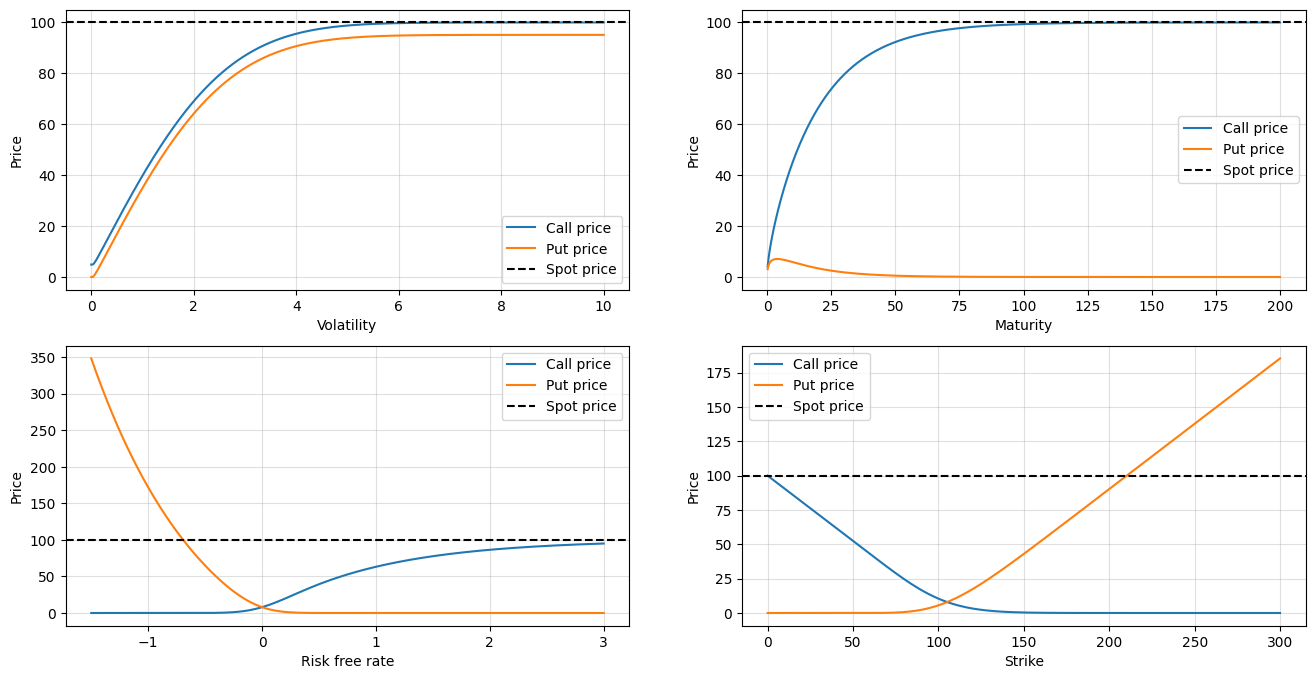

In [ ]:
vol_list = np.linspace(0, 10, 1000)
maturities_list = np.linspace(0, 200, 1000)
rates_list = np.linspace(-1.5, 3, 1000)
strikes_list = np.linspace(0, 300, 1000)

call_vol = [call_price(S, K, T, r, vol) for vol in vol_list]
put_vol = [put_price(S, K, T, r, vol) for vol in vol_list]

call_mat = [call_price(S, K, mat, r, sigma) for mat in maturities_list]
put_mat = [put_price(S, K, mat, r, sigma) for mat in maturities_list]

call_rate = [call_price(S, K, T, rate, sigma) for rate in rates_list]
put_rate = [put_price(S, K, T, rate, sigma) for rate in rates_list]

call_strike = [call_price(S, strike, T, r, sigma) for strike in strikes_list]
put_strike = [put_price(S, strike, T, r, sigma) for strike in strikes_list]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

ax[0,0].plot(vol_list, call_vol, label='Call price')
ax[0,0].plot(vol_list, put_vol, label='Put price')
ax[0,0].axhline(S, linestyle='--', color='black', label='Spot price')
ax[0,0].set_xlabel('Volatility')
ax[0,0].set_ylabel('Price')
ax[0,0].legend()
ax[0,0].grid(True, alpha=0.4)

ax[0,1].plot(maturities_list, call_mat, label='Call price')
ax[0,1].plot(maturities_list, put_mat, label='Put price')
ax[0,1].axhline(S, linestyle='--', color='black', label='Spot price')
ax[0,1].set_xlabel('Maturity')
ax[0,1].set_ylabel('Price')
ax[0,1].legend()
ax[0,1].grid(True, alpha=0.4)

ax[1,0].plot(rates_list, call_rate, label='Call price')
ax[1,0].plot(rates_list, put_rate, label='Put price')
ax[1,0].axhline(S, linestyle='--', color='black', label='Spot price')
ax[1,0].set_xlabel('Risk free rate')
ax[1,0].set_ylabel('Price')
ax[1,0].legend()
ax[1,0].grid(True, alpha=0.4)

ax[1,1].plot(strikes_list, call_strike, label='Call price')
ax[1,1].plot(strikes_list, put_strike, label='Put price')
ax[1,1].axhline(S, linestyle='--', color='black', label='Spot price')
ax[1,1].set_xlabel('Strike')
ax[1,1].set_ylabel('Price')
ax[1,1].legend()
ax[1,1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

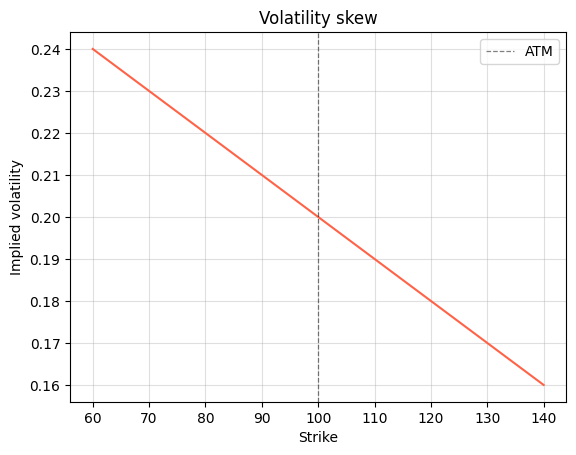

In [ ]:
def market_vol(K, S=100):
    moneyness = K / S
    return 0.2 + 0.1 * (1 - moneyness)

strikes = np.linspace(60, 140, 200)
impliedVolCall = [implied_volatility(call_price(S, strike, T, r, market_vol(strike, S)), S, strike, T, r, option_type='call')
                  for strike in strikes ]

plt.plot(strikes, impliedVolCall, color='tomato')
plt.title('Volatility skew')
plt.xlabel('Strike')
plt.ylabel('Implied volatility')
plt.axvline(x=S, color='black', linestyle='--', linewidth=0.9, alpha=0.5, label='ATM')
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()